In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
df = pd.read_csv('Phishing_URL_ds_feature_engineered_train.csv')

In [24]:
########################################


X_input = df.drop(columns=['label']) 
y_input = df['label']      

# 1. APPLY PCA
# We calculate the top 3 components directly
pca = PCA(n_components=3)
X_pca_values = pca.fit_transform(X_input)

# Convert results to a DataFrame for easy plotting
df_pca_result = pd.DataFrame(X_pca_values, columns=['PC1', 'PC2', 'PC3'])
df_pca_result['label'] = y_input.values

# Check Variance Explained
var_ratio = pca.explained_variance_ratio_
print(f"Variance Explained by Components:")
print(f"PC1: {var_ratio[0]*100:.2f}%")
print(f"PC2: {var_ratio[1]*100:.2f}%")
print(f"PC3: {var_ratio[2]*100:.2f}%")
print(f"Total Variance Explained: {sum(var_ratio)*100:.2f}%")

Variance Explained by Components:
PC1: 25.85%
PC2: 8.42%
PC3: 6.08%
Total Variance Explained: 40.35%


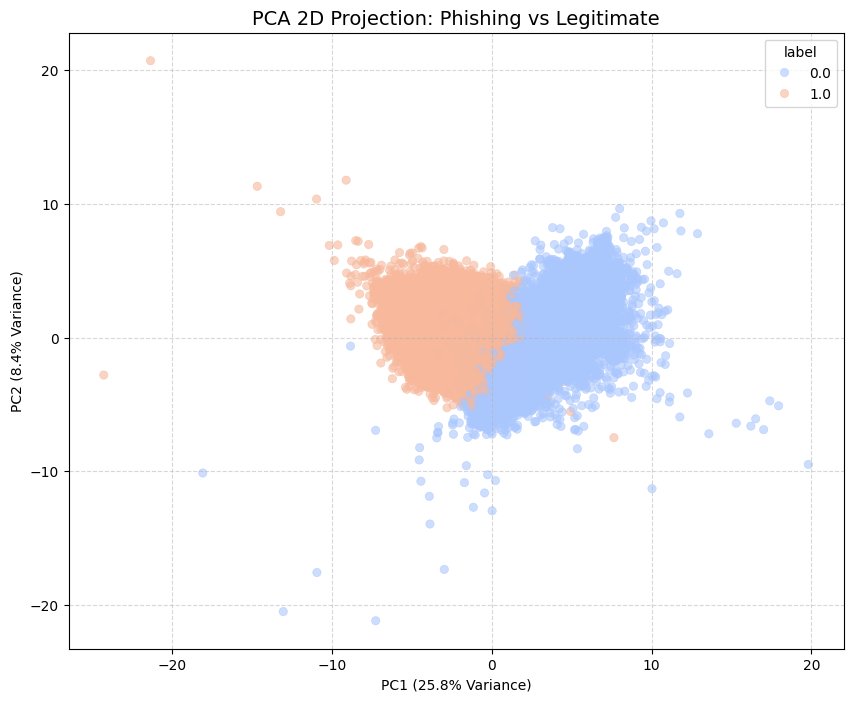

In [25]:
# --- 2. 2D VISUALIZATION (PC1 vs PC2) ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='label', 
    data=df_pca_result, 
    palette='coolwarm', # Blue for 0 (Legit), Red for 1 (Phishing)
    alpha=0.6,
    edgecolor=None
)
plt.title('PCA 2D Projection: Phishing vs Legitimate', fontsize=14)
plt.xlabel(f"PC1 ({var_ratio[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({var_ratio[1]*100:.1f}% Variance)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

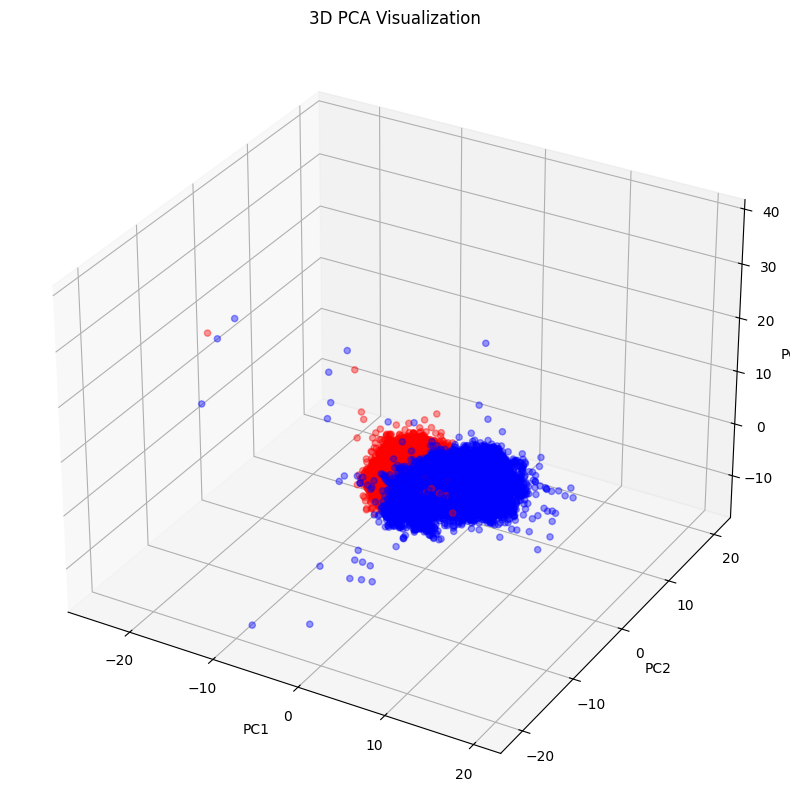

In [26]:
# --- 3. 3D VISUALIZATION (PC1 vs PC2 vs PC3) ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Map colors: 0 -> Blue, 1 -> Red
colors = df_pca_result['label'].map({0: 'blue', 1: 'red'})

ax.scatter(
    df_pca_result['PC1'], 
    df_pca_result['PC2'], 
    df_pca_result['PC3'], 
    c=colors, 
    alpha=0.4, 
    s=20
)
ax.set_title('3D PCA Visualization')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()


=== Top 5 Features driving PC1 (X-Axis) ===
NoOfOtherSpecialCharsInURL    0.250265
NoOfJS                        0.249397
HasSocialNet                  0.242161
NoOfSelfRef                   0.231297
NoOfImage                     0.224564
Name: PC1_Weight, dtype: float64

=== Top 5 Features driving PC2 (Y-Axis) ===
DomainLength        0.349875
URLLength           0.349244
NoOfLettersInURL    0.322466
LetterRatioInURL    0.263144
NoOfSubDomain       0.212005
Name: PC2_Weight, dtype: float64

=== Top 5 Features driving PC3 (Z-Axis) ===
Domain_Weight            0.414443
DomainLength             0.317171
LetterRatioInURL         0.310476
SpacialCharRatioInURL    0.274619
TLDLength                0.271214
Name: PC3_Weight, dtype: float64


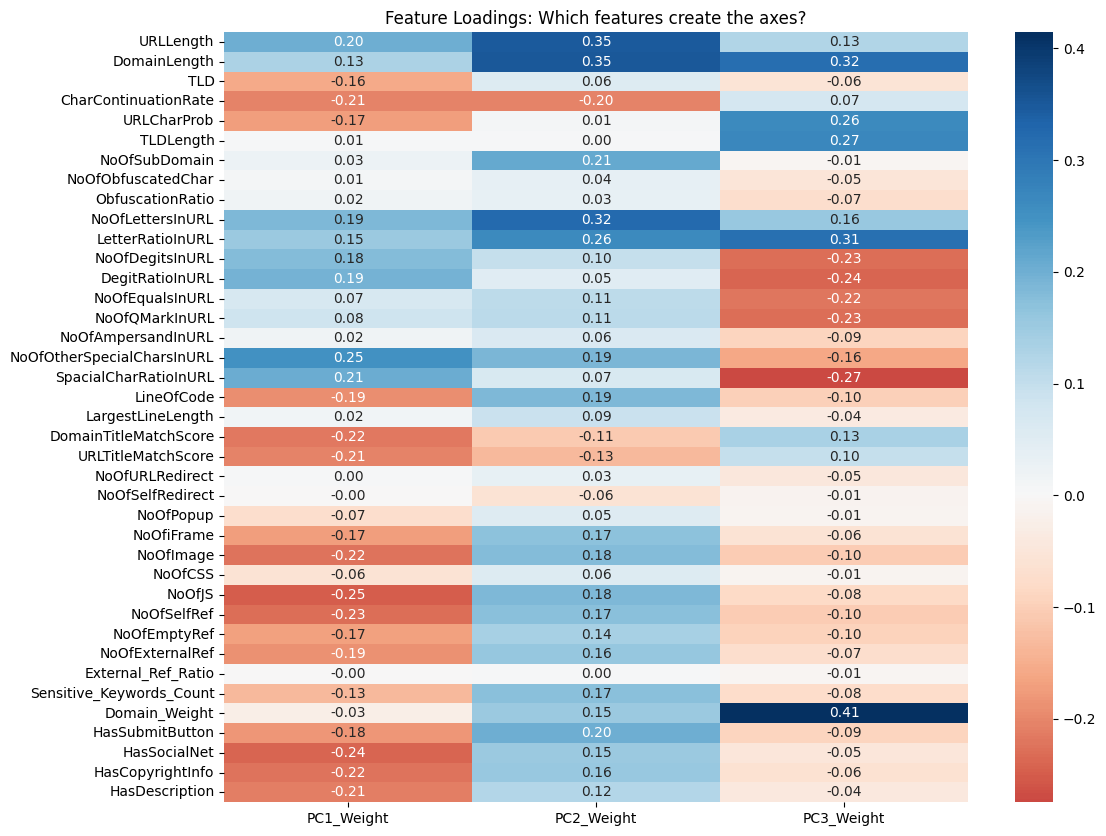

In [27]:
# Get feature names from your scaled dataframe
feature_names = X_input.columns 

# Get the Principal Component Coefficients (Eigenvectors)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1_Weight', 'PC2_Weight', 'PC3_Weight'], 
    index=feature_names
)

# --- ANALYSIS OUTPUT ---
print("\n=== Top 5 Features driving PC1 (X-Axis) ===")
# Sort by absolute value to see the strongest drivers
print(loadings['PC1_Weight'].abs().sort_values(ascending=False).head(5))

print("\n=== Top 5 Features driving PC2 (Y-Axis) ===")
print(loadings['PC2_Weight'].abs().sort_values(ascending=False).head(5))

print("\n=== Top 5 Features driving PC3 (Z-Axis) ===")
print(loadings['PC3_Weight'].abs().sort_values(ascending=False).head(5))

# Visualization: Heatmap of Loadings
plt.figure(figsize=(12, 10))
sns.heatmap(loadings, cmap='RdBu', center=0, annot=True, fmt=".2f")
plt.title("Feature Loadings: Which features create the axes?")
plt.show()

Data is large (156808 rows). Sampling 3000 for visualization...
Visualization Set Shape: (3000, 39)
Running t-SNE... (This takes a moment)
Running UMAP... (Usually faster)


/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


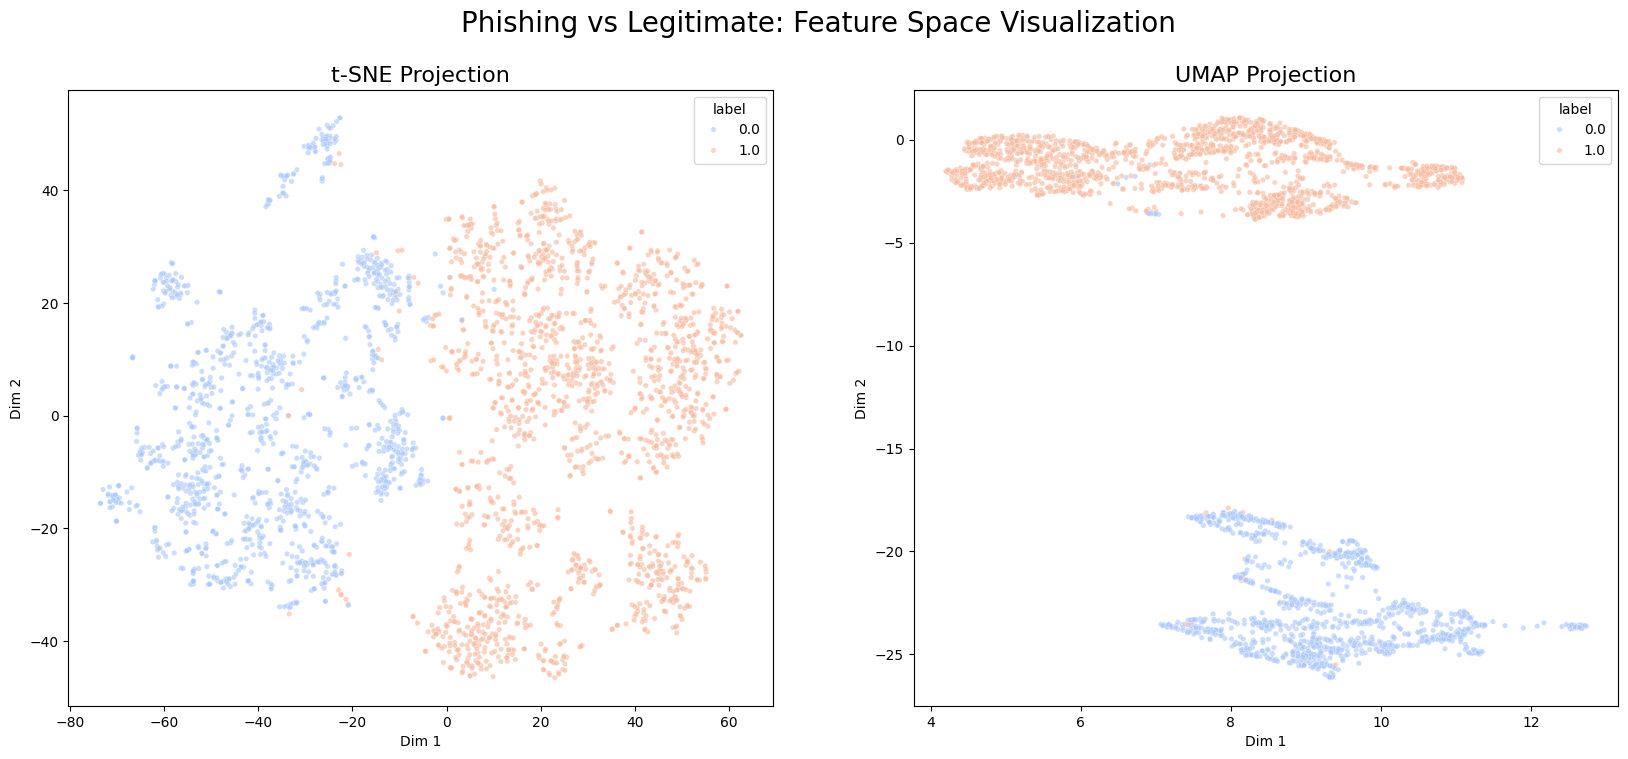

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap

X_train = df.drop(columns=['label'])
y_train = df['label']
# 1. SAMPLING (Optional but Recommended for Speed)
# If your data is huge, t-SNE will take forever. Let's take a sample of 3000 points.
# If your data is small (<5000 rows), you can skip this block.
sample_size = 3000
if len(X_train) > sample_size:
    print(f"Data is large ({len(X_train)} rows). Sampling {sample_size} for visualization...")
    # Sample indices
    indices = np.random.choice(X_train.index, sample_size, replace=False)
    X_vis = X_train.loc[indices]
    y_vis = y_train.loc[indices]
else:
    print("Data is small enough. Using full dataset.")
    X_vis = X_train
    y_vis = y_train

print(f"Visualization Set Shape: {X_vis.shape}")

# --- 2. RUN t-SNE ---
print("Running t-SNE... (This takes a moment)")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
tsne_results = tsne.fit_transform(X_vis)

# --- 3. RUN UMAP ---
print("Running UMAP... (Usually faster)")
# n_neighbors=30: Balances local and global structure
# min_dist=0.1:  Controls how tightly points are packed
umap_reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
umap_results = umap_reducer.fit_transform(X_vis)

# --- 4. PLOTTING SIDE-BY-SIDE ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot t-SNE
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue=y_vis, palette='coolwarm', alpha=0.6, s=15, ax=axes[0]
)
axes[0].set_title('t-SNE Projection', fontsize=16)
axes[0].set_xlabel('Dim 1')
axes[0].set_ylabel('Dim 2')

# Plot UMAP
sns.scatterplot(
    x=umap_results[:,0], y=umap_results[:,1],
    hue=y_vis, palette='coolwarm', alpha=0.6, s=15, ax=axes[1]
)
axes[1].set_title('UMAP Projection', fontsize=16)
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')

plt.suptitle("Phishing vs Legitimate: Feature Space Visualization", fontsize=20)
plt.show()